# Preparação de Dados — Dataset PCOS (Síndrome dos Ovários Policísticos)

**Notebook de DATA PREP passo a passo**

Este notebook mostra a limpeza e preparação.

> **Objetivo:** partir dos dados brutos (com todos os seus problemas reais) e chegar a um
> `pcos_clean.csv` — 100% numérico, sem nulos e pronto para a etapa de **modelagem/treino**.
>
> A ideia é dominar bem a fase de preparação, que costuma ser 70% do trabalho em ML.

**Fluxo do notebook:**
`Carregar → Diagnosticar → Limpar nomes → Remover colunas → Corrigir tipos → Tratar nulos → Outliers → Target → Feature eng. → Exportar`


## 0. Setup — Instalação e Imports

Instalando as bibliotecas necessárias: `pandas`, `numpy`, `matplotlib` e
`seaborn` já vêm instalados; `openpyxl` (para ler Excel).


In [2]:
# Instalando bibliotecas necessárias
# Descomente a linha abaixo se estiver e faltar alguma lib:
# !pip install -q openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais para os gráficos ficarem mais legíveis
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 60)  # ver todas as colunas no .head()

print("Bibliotecas importadas com sucesso ✅")

Bibliotecas importadas com sucesso ✅


## 1. Carregar os Dados

O dataset vem em um arquivo **Excel** (`PCOS_data_without_infertility.xlsx`) e os dados que nos
interessam estão na planilha (sheet) chamada **`Full_new`**.

Usando o arquivo da pasta docs. 

In [4]:
# Caminho do arquivo (ajuste conforme a opção A ou B acima)
arquivo = "../datasets/PCOS_data_without_infertility.xlsx"

# Lemos a planilha "Full_new" — é onde estão os dados completos
df = pd.read_excel(arquivo, sheet_name="Full_new")

# Guardamos o estado INICIAL para comparar no final (evolução do dataset)
shape_inicial = df.shape
print(f"Estado inicial do dataset: {shape_inicial[0]} linhas × {shape_inicial[1]} colunas")
df.head()

Estado inicial do dataset: 541 linhas × 45 colunas


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


### Primeira olhada com `.info()`

O `.info()` mostra o tipo (dtype) de cada coluna e quantos valores não-nulos ela tem.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

## 2. Diagnóstico de Qualidade dos Dados

Um bom pré-processamento começa entendendo *quais* são os problemas.


### 2.1 Colunas que deveriam ser numéricas mas estão como texto (`object`)

Se uma coluna de exame (hormônio) aparece como `object` em vez de `float`, é sinal de que
existe algum **valor não-numérico "sujo"** escondido nela.


In [4]:
# Listamos as colunas do tipo 'object' (texto). Colunas de exames NÃO deveriam estar aqui.
colunas_texto = df.select_dtypes(include="object").columns.tolist()
print("Colunas lidas como TEXTO (object):", colunas_texto)

Colunas lidas como TEXTO (object): ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Unnamed: 44']


In [5]:
# Vamos descobrir QUAL valor está sujando cada coluna numérica.
# A técnica: tentar converter para número; o que virar NaN é o culpado.
for col in ["II    beta-HCG(mIU/mL)", "AMH(ng/mL)"]:
    convertido = pd.to_numeric(df[col], errors="coerce")   # valores inválidos viram NaN
    # Mostra as linhas onde a conversão falhou (valor original problemático)
    problematicos = df.loc[convertido.isna() & df[col].notna(), col].unique()
    print(f"Coluna '{col}': valores problemáticos -> {problematicos}")

Coluna 'II    beta-HCG(mIU/mL)': valores problemáticos -> ['1.99.']
Coluna 'AMH(ng/mL)': valores problemáticos -> ['a']


💡 **Achado:** a coluna `II beta-HCG` tem o valor `'1.99.'` (com **dois pontos**) e a
`AMH` tem a letra `'a'`. São erros de digitação na planilha original. Vamos corrigir na etapa 5.


### 2.2 Valores nulos por coluna

Vamos ver quantos valores faltantes (NaN) existem em cada coluna.


In [6]:
# Conta os nulos por coluna e mostra apenas as que têm pelo menos 1 nulo
nulos = df.isna().sum()
print("Nulos por coluna (apenas colunas com nulos):")
print(nulos[nulos > 0])

Nulos por coluna (apenas colunas com nulos):
Marraige Status (Yrs)      1
Fast food (Y/N)            1
Unnamed: 44              539
dtype: int64


💡 **Achado:** a coluna `Unnamed: 44` está **quase toda vazia** (é uma coluna "fantasma"
que o Excel trouxe por engano). Também há nulos pontuais em `Marraige Status (Yrs)` e `Fast food (Y/N)`.


### 2.3 Colunas de identificação (não são features)

`Sl. No` e `Patient File No.` são apenas **números de registro** do paciente. Não têm
poder preditivo e, se deixadas, podem até atrapalhar o modelo. Vão ser removidas.


In [7]:
# Espiando as colunas de ID — são só contadores sequenciais
df[["Sl. No", "Patient File No."]].head()

,Sl. No,Patient File No.
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5


### Resumo do diagnóstico

| # | Problema encontrado | Como vamos tratar |
|---|---|---|
| 1 | Nomes de colunas com espaços extras e erros de digitação | Limpar com `.str.strip()` (etapa 3) |
| 2 | `II beta-HCG` é texto por causa de `'1.99.'` | Converter para numérico (etapa 5) |
| 3 | `AMH` é texto por causa de `'a'` | Converter para numérico (etapa 5) |
| 4 | Coluna `Unnamed: 44` quase vazia | Remover (etapa 4) |
| 5 | IDs `Sl. No` e `Patient File No.` | Remover (etapa 4) |
| 6 | Nulos pontuais + gerados pela conversão | Imputar com a mediana (etapa 6) |


## 3. Limpeza dos Nomes das Colunas

Vários nomes têm **espaços no começo/fim** (ex.: `' Age (yrs)'`, `'Height(Cm) '`). Ideal padronizar tudo com `.str.strip()`.


In [8]:
# Mostra alguns nomes ANTES (com aspas para enxergar os espaços)
print("ANTES:")
for c in list(df.columns)[:8]:
    print(repr(c))

ANTES:
'Sl. No'
'Patient File No.'
'PCOS (Y/N)'
' Age (yrs)'
'Weight (Kg)'
'Height(Cm) '
'BMI'
'Blood Group'


In [9]:
# .str.strip() remove espaços no início e no fim de cada nome de coluna
df.columns = df.columns.str.strip()

print("DEPOIS:")
for c in list(df.columns)[:8]:
    print(repr(c))

DEPOIS:
'Sl. No'
'Patient File No.'
'PCOS (Y/N)'
'Age (yrs)'
'Weight (Kg)'
'Height(Cm)'
'BMI'
'Blood Group'


> 💡 Foi mantido os nomes originais (apenas sem os espaços) para o notebook ficar fiel ao dataset.
> Se quiser, pode padronizar mais tarde (ex.: renomear `Marraige` → `Marriage`).


## 4. Remover Colunas Irrelevantes

Foram removidas as colunas que não ajudam o modelo:
- **`Sl. No`** e **`Patient File No.`** → apenas identificadores
- **`Unnamed: 44`** → coluna fantasma quase toda vazia


In [10]:
# errors="ignore" evita erro caso alguma coluna já não exista
colunas_para_remover = ["Sl. No", "Patient File No.", "Unnamed: 44"]
df = df.drop(columns=colunas_para_remover, errors="ignore")

print(f"Colunas removidas: {colunas_para_remover}")
print(f"Novo shape: {df.shape[0]} linhas × {df.shape[1]} colunas")

Colunas removidas: ['Sl. No', 'Patient File No.', 'Unnamed: 44']
Novo shape: 541 linhas × 42 colunas


## 5. Corrigir Tipos de Dados / Valores Inválidos

Agora convertendo as duas colunas hormonais que estavam como texto para **numérico**.
Usamos `pd.to_numeric(errors="coerce")`: os valores válidos viram número e os inválidos
(`'1.99.'`, `'a'`) viram **NaN** — que trataremos na próxima etapa junto com os demais nulos.


In [11]:
colunas_corrigir = ["II    beta-HCG(mIU/mL)", "AMH(ng/mL)"]

# Após o strip da etapa 3, os nomes podem ter perdido espaços internos? Não —
# strip só mexe nas pontas. Mas o nome de beta-HCG tem espaços NO MEIO. Vamos localizar
# os nomes reais de forma robusta, procurando por trechos-chave:
def achar_coluna(trecho):
    for c in df.columns:
        if trecho.lower() in c.lower():
            return c
    return None

col_hcg = achar_coluna("II") if achar_coluna("beta-HCG") is None else achar_coluna("beta-HCG")
# Mais direto: pegar as colunas que ainda são 'object'
col_objs = df.select_dtypes(include="object").columns.tolist()
print("Colunas ainda em texto a converter:", col_objs)

for col in col_objs:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nTipos após conversão:")
print(df.select_dtypes(include="object").columns.tolist(), "= nenhuma coluna de texto restante ✅")

Colunas ainda em texto a converter: ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']

Tipos após conversão:
[] = nenhuma coluna de texto restante ✅


## 6. Tratar Valores Ausentes

Recontando os nulos — agora incluindo os que **acabaram de gerar** ao converter os valores
inválidos. Uma estratégia é preencher com a **mediana** de cada coluna.

> 💡 **Por que mediana e não média?** A mediana é **robusta a outliers**. Exames hormonais
> costumam ter valores extremos; se usasse a média, esses extremos puxariam o valor de
> preenchimento para cima. A mediana (valor do meio) não sofre esse efeito.


In [12]:
# Nulos ANTES da imputação
nulos_antes = df.isna().sum()
print("Nulos antes da imputação:")
print(nulos_antes[nulos_antes > 0])

Nulos antes da imputação:
Marraige Status (Yrs)     1
II    beta-HCG(mIU/mL)    1
AMH(ng/mL)                1
Fast food (Y/N)           1
dtype: int64


In [13]:
# Preenche cada coluna numérica com a sua mediana
for col in df.columns:
    if df[col].isna().any():
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"'{col}': {int(nulos_antes[col])} nulo(s) preenchido(s) com mediana = {mediana}")

print(f"\nTotal de nulos restantes: {df.isna().sum().sum()} ✅")

'Marraige Status (Yrs)': 1 nulo(s) preenchido(s) com mediana = 7.0
'II    beta-HCG(mIU/mL)': 1 nulo(s) preenchido(s) com mediana = 1.99
'AMH(ng/mL)': 1 nulo(s) preenchido(s) com mediana = 3.7
'Fast food (Y/N)': 1 nulo(s) preenchido(s) com mediana = 1.0

Total de nulos restantes: 0 ✅


## 7. Detecção de Outliers (Exploração Visual)

Vamos **apenas visualizar** possíveis outliers com boxplots. Cada ponto além dos "bigodes"
do boxplot é um candidato a outlier.

> ⚠️ **Cuidado em dados médicos:** um valor extremo pode ser **clinicamente real** (uma
> paciente com hormônio de fato muito alto). Remover outliers às cegas pode apagar justamente
> os casos mais importantes. Por isso aqui só **observamos** — a decisão de tratar (ou não)
> deve ser consciente.


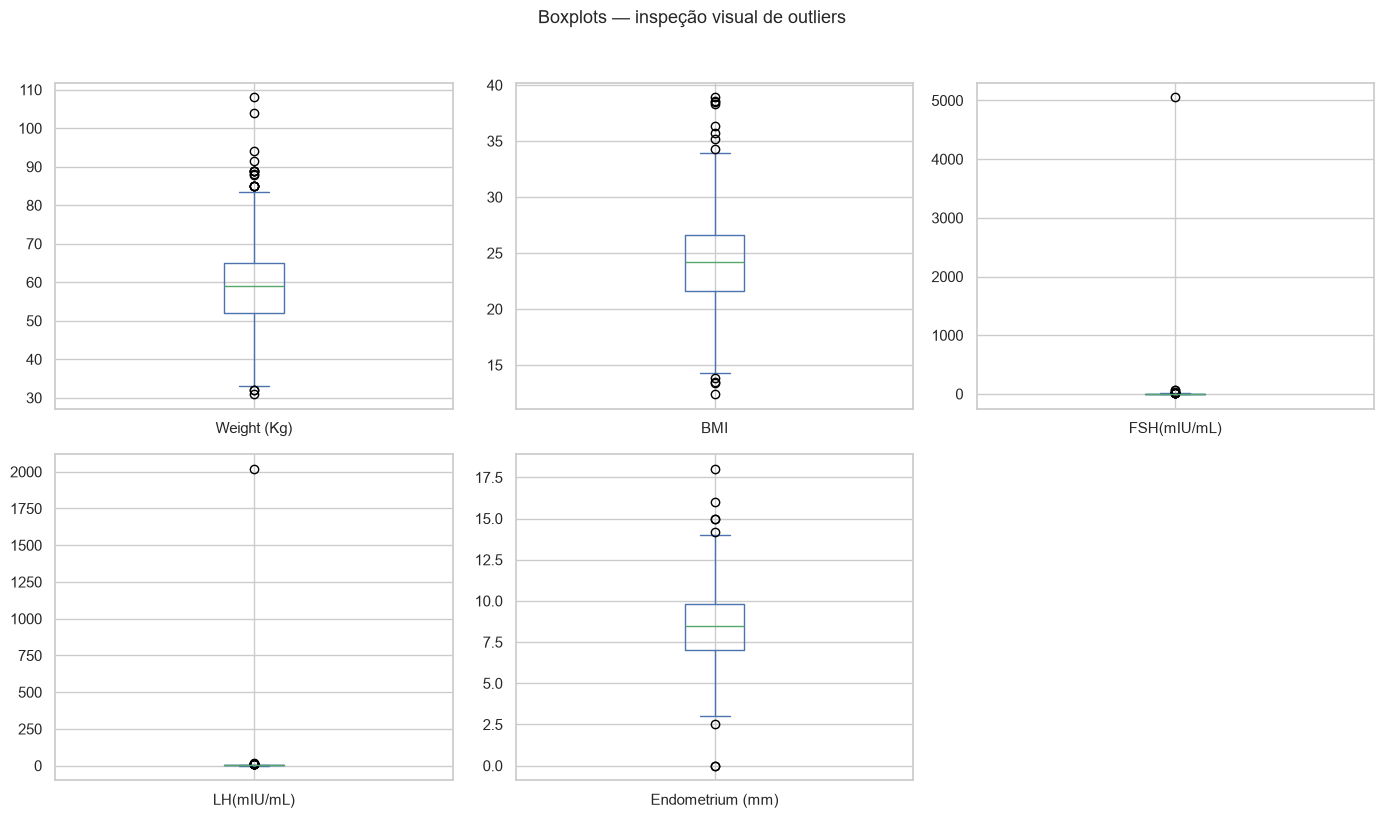

In [5]:
# Escolhemos algumas features contínuas para inspecionar
features_continuas = ["Weight (Kg)", "BMI", "FSH(mIU/mL)", "LH(mIU/mL)",
                      "AMH(ng/mL)", "Endometrium (mm)"]
# Mantém só as que existem de fato no df (por segurança)
features_continuas = [c for c in features_continuas if c in df.columns]

df[features_continuas].plot(kind="box", subplots=True, layout=(2, 3),
                            figsize=(14, 8), sharex=False, sharey=False)
plt.suptitle("Boxplots — inspeção visual de outliers", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Análise do Target e Balanceamento

A variável para prever é **`PCOS (Y/N)`**: `1` = tem PCOS, `0` = não tem.
Verificando se as classes estão equilibradas.


Contagem por classe:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Percentual:
PCOS (Y/N)
0    67.3
1    32.7
Name: proportion, dtype: float64


/tmp/ipykernel_1708/2881429892.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target, data=df, palette="Set2")


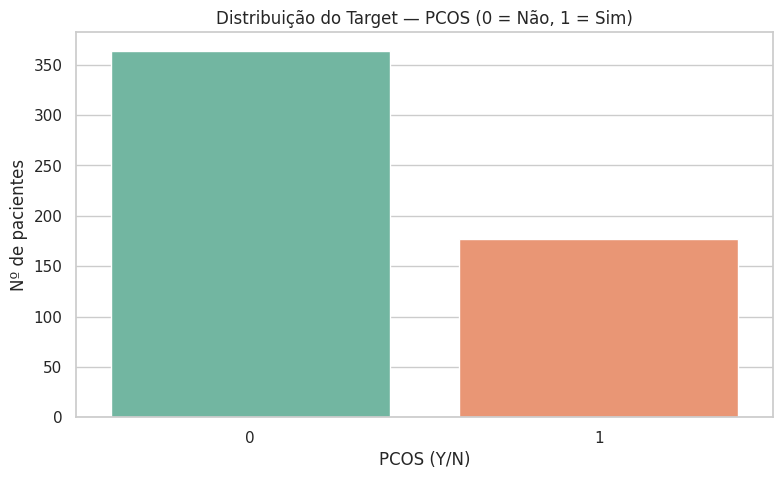

In [15]:
target = "PCOS (Y/N)"
contagem = df[target].value_counts()
percentual = df[target].value_counts(normalize=True) * 100

print("Contagem por classe:")
print(contagem)
print("\nPercentual:")
print(percentual.round(1))

# Gráfico de barras do balanceamento
ax = sns.countplot(x=target, data=df, palette="Set2")
ax.set_title("Distribuição do Target — PCOS (0 = Não, 1 = Sim)")
ax.set_xlabel("PCOS (Y/N)")
ax.set_ylabel("Nº de pacientes")
plt.show()

💡 **Interpretação:** cerca de **1/3 das pacientes** têm PCOS (classe levemente
desbalanceada). Isso tem duas consequências práticas para a modelagem:

1. **Use `stratify=y`** ao dividir treino/teste, para manter a proporção das classes.
2. **Não confie só na acurácia.** Priorize **Recall** e **F1-Score** — em diagnóstico, o pior
   erro é dizer que uma paciente doente está saudável (falso negativo).


## 9. Feature Engineering (leve)

O dataset já traz algumas **features derivadas** clinicamente muito relevantes:

- **`FSH/LH`** — a razão entre os hormônios FSH e LH. Em PCOS é comum a razão LH/FSH estar
  alterada, então essa proporção é um forte indicador.
- **`Waist:Hip Ratio`** — relação cintura/quadril, ligada à distribuição de gordura corporal.

Como exemplo didático, vamos criar mais uma feature simples: a razão **folículos/idade**
(apenas para ilustrar o conceito — você pode remover se não fizer sentido no seu modelo).


In [16]:
# Exemplo de criação de feature (ilustrativo). Usamos os nomes já limpos.
if "Follicle No. (L)" in df.columns and "Follicle No. (R)" in df.columns:
    df["Total Follicles"] = df["Follicle No. (L)"] + df["Follicle No. (R)"]
    print("Nova feature criada: 'Total Follicles' (soma dos folículos esquerdo + direito)")

df[["Follicle No. (L)", "Follicle No. (R)", "Total Follicles"]].head()

Nova feature criada: 'Total Follicles' (soma dos folículos esquerdo + direito)


,Follicle No. (L),Follicle No. (R),Total Follicles
0,3,3,6
1,3,5,8
2,13,15,28
3,2,2,4
4,3,4,7


> 💡 Feature engineering é opcional nesta fase. O importante é entender que **conhecimento
> do domínio** (aqui, ginecologia/endocrinologia) ajuda a criar variáveis mais informativas.


## 10. Prontidão para ML — As Features Estão na Mesma "Régua"?

Antes de declarar que o dataset está **pronto para treino**, um bom analista faz mais uma
pergunta importante:

> ❓ **"As minhas features estão em escalas comparáveis? Preciso escalonar (normalizar)?"**

Essa é uma etapa de análise que muita gente pula — e depois não entende por que o modelo
foi mal. Vamos raciocinar sobre isso do jeito humano: **investigar → decidir → justificar**.


### 10.1 Investigar: comparar as escalas das features

**Raciocínio:** se uma feature vai de 0 a 1 e outra vai de 0 a 5000, elas estão em "réguas"
completamente diferentes. Vamos medir o **range (max - min)** de cada coluna para enxergar
essa diferença de escala.


In [17]:
# Calcula min, max e range (amplitude) de cada feature numérica
# Removemos o target da análise (ele não é escalonado)
target = "PCOS (Y/N)"
features = df.drop(columns=[target])

resumo_escala = pd.DataFrame({
    "min": features.min(),
    "max": features.max(),
    "range": features.max() - features.min(),
})
# Ordena da maior para a menor amplitude — as "gigantes" aparecem no topo
resumo_escala = resumo_escala.sort_values("range", ascending=False)
print("📏 Escala das features (ordenado pela amplitude):")
resumo_escala.head(15)

📏 Escala das features (ordenado pela amplitude):


,min,max,range
I beta-HCG(mIU/mL),1.300000,32460.970000,32459.670000
II beta-HCG(mIU/mL),0.990000,25000.000000,24999.010000
Vit D3 (ng/mL),0.000000,6014.660000,6014.660000
FSH(mIU/mL),0.210000,5052.000000,5051.790000
LH(mIU/mL),0.020000,2018.000000,2017.980000
FSH/LH,0.002146,1372.826087,1372.823941
RBS(mg/dl),60.000000,350.000000,290.000000
BP _Systolic (mmHg),12.000000,140.000000,128.000000
PRL(ng/mL),0.400000,128.240000,127.840000
BP _Diastolic (mmHg),8.000000,100.000000,92.000000


**🤔 O que observar:**

- [ ] Qual a feature com **maior** amplitude? (provavelmente algum hormônio ou beta-HCG)
- [ ] Qual a feature com **menor** amplitude? (os sintomas binários Y/N, que vão de 0 a 1)
- [ ] A razão entre a maior e a menor é grande?

**📝 Anotação:** repare que temos features indo de **0 a 1** (sintomas binários) convivendo
com features que chegam a **centenas ou milhares** (beta-HCG, RBS, exames). Isso é uma
diferença de escala de **milhares de vezes**.


### 10.2 Visualizar a diferença de escala

Um gráfico deixa a discrepância óbvia. Vamos plotar a amplitude (range) das top features
em barras — a diferença salta aos olhos.


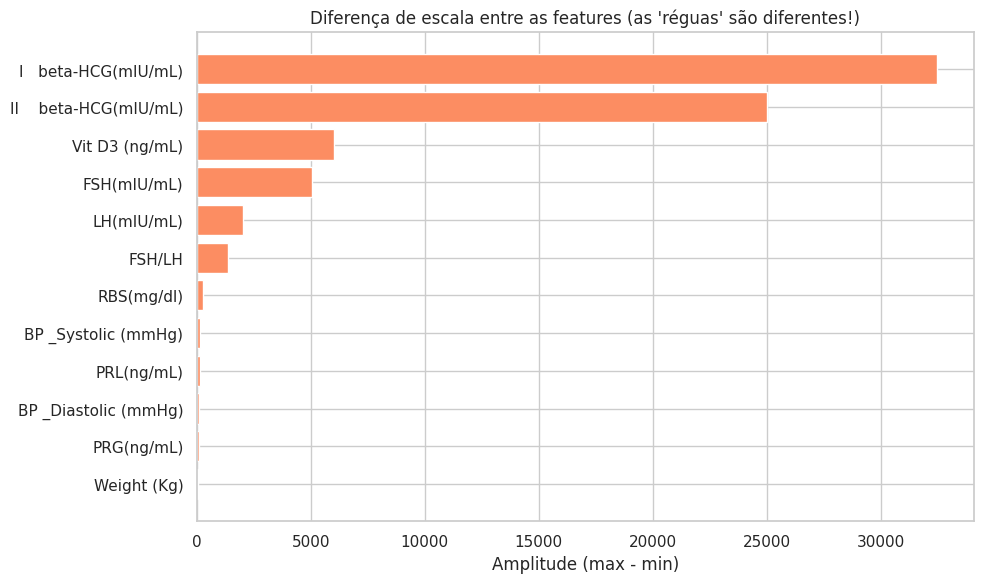

Maior amplitude: 32459.7
Menor amplitude (>0): 0.2
➡️  A maior é ~145161x maior que a menor!


In [18]:
import matplotlib.pyplot as plt

# Pega as 12 features de maior amplitude para o gráfico
top = resumo_escala.head(12).sort_values("range")

plt.figure(figsize=(10, 6))
plt.barh(top.index, top["range"], color="#fc8d62")
plt.xlabel("Amplitude (max - min)")
plt.title("Diferença de escala entre as features (as 'réguas' são diferentes!)")
plt.tight_layout()
plt.show()

# Mostra numericamente a discrepância
maior = resumo_escala["range"].max()
menor = resumo_escala[resumo_escala["range"] > 0]["range"].min()
print(f"Maior amplitude: {maior:.1f}")
print(f"Menor amplitude (>0): {menor:.1f}")
print(f"➡️  A maior é ~{maior/menor:.0f}x maior que a menor!")

> 💡 **Por que isso é um problema?** Alguns algoritmos calculam **distâncias** entre os
> pontos (KNN, SVM) ou usam **gradiente** (Regressão Logística, Redes Neurais). Se uma feature
> tem valores muito maiores, ela vai **dominar** o cálculo — o modelo "acha" que ela é mais
> importante só porque os números são maiores, não porque ela realmente ajuda a prever PCOS.
>
> Exemplo intuitivo: no cálculo de distância, uma diferença de `5000` em beta-HCG esmaga uma
> diferença de `1` em "tem hirsutismo (sim/não)" — mesmo que o hirsutismo seja clinicamente
> mais relevante para PCOS.


### 10.3 Decidir: EU preciso escalonar? Depende do algoritmo!

Aqui está o raciocínio que um humano faz. **Nem todo algoritmo precisa de escalonamento:**

| Algoritmo | Precisa escalonar? | Por quê |
|---|---|---|
| **KNN** | ✅ SIM | Baseado em distância — escala domina o cálculo |
| **SVM** | ✅ SIM | Baseado em distância/margem |
| **Regressão Logística** | ✅ SIM | Usa gradiente; converge melhor e coeficientes ficam comparáveis |
| **Redes Neurais** | ✅ SIM | Gradiente sensível à escala |
| **Árvore de Decisão** | ❌ NÃO | Decide por limiares (>, <) em cada feature isoladamente |
| **Random Forest** | ❌ NÃO | Conjunto de árvores — mesma lógica |
| **Gradient Boosting / XGBoost** | ❌ NÃO | Baseado em árvores |

**📝 Conclusão:** como no Tech Challenge vamos comparar **vários** modelos (incluindo KNN,
SVM e Regressão Logística), **precisamos escalonar**. Mesmo para os modelos baseados em
árvore, escalonar não atrapalha — então padronizamos para todos.


### 10.4 Decidir: `StandardScaler` ou `MinMaxScaler`?

As duas ferramentas mais comuns de escalonamento:

| | `StandardScaler` | `MinMaxScaler` |
|---|---|---|
| O que faz | Centraliza em média 0, desvio 1 (z-score) | Comprime tudo para o intervalo [0, 1] |
| Fórmula | `(x - média) / desvio` | `(x - min) / (max - min)` |
| Sensível a outliers? | Menos sensível | **Muito** sensível (outlier estica a régua) |
| Quando usar | Distribuição ~normal / há outliers | Dados limitados, sem outliers extremos |

**🤔 Como decidir no nosso caso?** Vimos na **Etapa 7 (boxplots)** que os hormônios têm
**outliers** (valores extremos clinicamente reais). Como o `MinMaxScaler` é muito sensível a
outliers (um único valor gigante espreme todos os outros perto de 0), o **`StandardScaler` é
a escolha mais segura** aqui.

> 📝 **Decisão justificada:** vamos usar **`StandardScaler`** por causa dos outliers nos exames
> hormonais.


### 10.5 Onde escalonar? NUNCA no CSV salvo — sempre no Pipeline do treino!

Este é **o erro mais comum** de quem está começando. Preste muita atenção:

**❌ ERRADO — escalonar o dataset inteiro e salvar:**
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # ❌ viu treino E teste juntos!
```
Isso causa **data leakage** (vazamento de dados): o scaler calcula a média/desvio usando
TAMBÉM os dados de teste, ou seja, o modelo "espia o futuro". A avaliação fica otimista demais
e mentirosa.

**✅ CERTO — escalonar dentro de um Pipeline, depois do split:**
```python
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1) Split PRIMEIRO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 2) Scaler DENTRO do pipeline: aprende (fit) só no treino, aplica nos dois
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", SEU_MODELO),
])
pipe.fit(X_train, y_train)   # fit do scaler acontece só com X_train
```

> 🎯 **Regra de ouro:** o `pcos_clean.csv` que vamos salvar fica **SEM escalonar** (com os
> valores reais). O escalonamento é responsabilidade da **etapa de modelagem**, dentro do
> pipeline, para não haver vazamento. Guardar o dado "cru limpo" também é melhor para a EDA,
> porque os valores continuam interpretáveis (um FSH de 5.0 continua sendo 5.0).


### 10.6 Demonstração (apenas ilustrativa — NÃO salva)

Só para você **ver** o efeito do `StandardScaler`, vamos aplicá-lo de forma ilustrativa e
comparar o "antes e depois" das estatísticas. Isto é apenas uma demonstração visual — **não**
usamos este resultado para salvar o CSV nem para treinar aqui.


In [19]:
from sklearn.preprocessing import StandardScaler

# APENAS demonstração: aplica no X inteiro só para visualizar o efeito
demo_scaler = StandardScaler()
X_demo = pd.DataFrame(demo_scaler.fit_transform(features), columns=features.columns)

print("ANTES do escalonamento (valores reais) — 3 features:")
print(features[["Weight (Kg)", "FSH(mIU/mL)", "BMI"]].describe().loc[["mean", "std", "min", "max"]].round(2))

print("\nDEPOIS do StandardScaler (média ~0, desvio ~1):")
print(X_demo[["Weight (Kg)", "FSH(mIU/mL)", "BMI"]].describe().loc[["mean", "std", "min", "max"]].round(2))

print("\n💡 Repare: depois do StandardScaler, TODAS as features passam a ter média ~0 e")
print("   desvio ~1 — ou seja, ficam na MESMA régua. Mas isso é feito no PIPELINE do treino,")
print("   não aqui no CSV.")

ANTES do escalonamento (valores reais) — 3 features:
      Weight (Kg)  FSH(mIU/mL)    BMI
mean        59.64        14.60  24.31
std         11.03       217.02   4.06
min         31.00         0.21  12.42
max        108.00      5052.00  38.90

DEPOIS do StandardScaler (média ~0, desvio ~1):
      Weight (Kg)  FSH(mIU/mL)   BMI
mean        -0.00        -0.00 -0.00
std          1.00         1.00  1.00
min         -2.60        -0.07 -2.93
max          4.39        23.23  3.60

💡 Repare: depois do StandardScaler, TODAS as features passam a ter média ~0 e
   desvio ~1 — ou seja, ficam na MESMA régua. Mas isso é feito no PIPELINE do treino,
   não aqui no CSV.


### 10.7 Checklist Final de Prontidão para Machine Learning

Antes de dizer "meu dataset está pronto para treinar", responda cada pergunta com evidência:

| # | Pergunta | Como verificar | Nosso caso |
|---|---|---|---|
| 1 | Todas as features são numéricas? | `df.select_dtypes('object')` vazio? | ✅ Sim |
| 2 | Existe algum valor nulo? | `df.isna().sum().sum() == 0`? | ✅ Zero |
| 3 | Removi IDs e colunas inúteis? | Conferir colunas | ✅ Sim |
| 4 | Corrigi valores inválidos? | beta-HCG e AMH numéricos? | ✅ Sim |
| 5 | Identifiquei o target? | `PCOS (Y/N)` | ✅ Sim |
| 6 | Sei se o target é desbalanceado? | `value_counts()` | ✅ ~33% positivos |
| 7 | Analisei as escalas das features? | `describe()` / ranges | ✅ Sim (muito diferentes) |
| 8 | Decidi se/como escalonar? | Depende do algoritmo | ✅ StandardScaler no pipeline |
| 9 | Sei evitar data leakage? | Escalar só no treino, via Pipeline | ✅ Sim |

**🎯 Se todas as respostas são ✅, o dataset está PRONTO.** Vamos fazer a verificação final e
exportar o `pcos_clean.csv` (com os valores reais, sem escalonar).


## 11. Verificação Final e Exportação

Conferimos o estado final: tudo numérico, zero nulos. Depois separamos **X** (features) e
**y** (target) e salvamos o dataset limpo em `pcos_clean.csv`.


In [20]:
# Verificação final
print("Tipos de dados (deve ser tudo numérico):")
print(df.dtypes.value_counts())
print(f"\nTotal de nulos: {df.isna().sum().sum()}")
df.info()

Tipos de dados (deve ser tudo numérico):
int64      22
float64    21
Name: count, dtype: int64

Total de nulos: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1   Age (yrs)               541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   541 non-null    float64
 12  Pregnant(Y/N)           541 non-nu

In [21]:
# Comparação: estado INICIAL vs FINAL (evidencia a evolução do dataset)
print("EVOLUÇÃO DO DATASET")
print("-" * 45)
print(f"{'':15}{'Inicial':>12}{'Final':>12}")
print(f"{'Linhas':15}{shape_inicial[0]:>12}{df.shape[0]:>12}")
print(f"{'Colunas':15}{shape_inicial[1]:>12}{df.shape[1]:>12}")
print(f"{'Colunas texto':15}{2:>12}{0:>12}")
print(f"{'Nulos':15}{'541 (Unnam.)':>12}{0:>12}")

EVOLUÇÃO DO DATASET
---------------------------------------------
                    Inicial       Final
Linhas                  541         541
Colunas                  45          43
Colunas texto             2           0
Nulos          541 (Unnam.)           0


In [22]:
# Separa features (X) e target (y)
target = "PCOS (Y/N)"
X = df.drop(columns=[target])
y = df[target]
print(f"X (features): {X.shape}")
print(f"y (target):   {y.shape}")

X (features): (541, 42)
y (target):   (541,)


In [ ]:
# Salva o dataset limpo. Este arquivo alimentará a etapa de MODELAGEM/TREINO.
df.to_csv("..datasets/pcos_clean.csv", index=False)
print("Arquivo 'pcos_clean.csv' salvo com sucesso ✅")
print("Pronto para a próxima fase: split treino/teste + escalonamento + modelagem.")

Arquivo 'pcos_clean.csv' salvo com sucesso ✅
Pronto para a próxima fase: split treino/teste + escalonamento + modelagem.
